# MCMC Orbit Fitting

The [maximum likelihood tutorial](../max_likelihood_orbit.ipynb) showed how to find the MAP orbit and compute likelihood gradients. Here we go one step further and sample the full posterior using [emcee](https://emcee.readthedocs.io/en/stable/), an affine-invariant ensemble sampler.

The second part of this notebook adds progressively more observations and overlays the resulting posteriors — a demonstration of how quickly the orbit uncertainty shrinks once a second opposition's worth of data is included.

Note that we don't do any of the stuff that you really should do when using MCMC, like checking for convergence, discarding burn-in, etc. This is just a quick demo of how to set up the sampler and visualize the results: when using MCMC for real, you should be much more careful about these things.

In [1]:
import jax

jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np

import astropy.units as u
import corner
import emcee
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
from astropy.time import Time
from astroquery.jplhorizons import Horizons

from jorbit import Observations, Particle
from jorbit.data.constants import SPEED_OF_LIGHT
from jorbit.utils.states import CartesianState

## Part 1: Single-opposition MCMC

We will use the same fake dataset as the maximum likelihood tutorial: nine astrometric observations of (274301) Wikipedia spread over three nights in January 2025, queried from JPL Horizons.

In [2]:
nights = [Time("2025-01-01 07:00"), Time("2025-01-02 07:00"), Time("2025-01-05 07:00")]

times = []
for n in nights:
    times.extend([n + i * 1 * u.hour for i in range(3)])
times = Time(times)

obj = Horizons(id="274301", location="695@399", epochs=times.utc.jd)
pts = obj.ephemerides(extra_precision=True, quantities="1")

coords = SkyCoord(pts["RA"], pts["DEC"], unit=(u.deg, u.deg))
times = Time(pts["datetime_jd"], format="jd", scale="utc")

obs = Observations(
    observed_coordinates=coords,
    times=times,
    observatories="kitt peak",
    astrometric_uncertainties=1 * u.arcsec,
)

For the initial state we pull the true barycentric state vector from Horizons. In practice you would start from a `max_likelihood` result; here we start at the truth to keep the notebook self-contained.

In [3]:
obj = Horizons(id="274301", location="500@0", epochs=times.tdb.jd[0])
vecs = obj.vectors(refplane="earth")
true_x0 = jnp.array([vecs["x"], vecs["y"], vecs["z"]]).T[0]
true_v0 = jnp.array([vecs["vx"], vecs["vy"], vecs["vz"]]).T[0]

p = Particle(
    x=true_x0,
    v=true_v0,
    time=times[0],
    name="274301 Wikipedia",
    observations=obs,
)

### The static integration path

When a `Particle` is created with observations, jorbit automatically builds a `static_residuals` function by precomputing the IAS15 step sizes and perturber (planet + asteroid) positions along the reference orbit. The precomputed data are frozen into a JIT-compiled closure, so each subsequent likelihood evaluation avoids rerunning the adaptive integrator and avoids re-querying the ephemeris — making it much faster for the thousands of calls that MCMC demands.

We can verify it is working by checking that the true-orbit residuals are near zero:

In [4]:
# static_residuals returns (n_obs, 2) tangent-plane residuals in arcseconds
print(p.static_residuals(p.cartesian_state))

[[-3.32660383e-07 -4.91174805e-07]
 [ 8.18208454e-07 -1.30179371e-06]
 [-5.41303605e-07 -1.09084419e-06]
 [-7.47107233e-07 -1.28947281e-06]
 [-7.57241205e-07  8.70551844e-07]
 [ 7.41829122e-07  9.18007346e-07]
 [ 9.92006244e-07  1.02686012e-06]
 [-1.70074093e-07 -3.05681937e-07]
 [-4.09222656e-07 -1.75906677e-07]]


### Defining the log-probability for emcee

emcee samples in a flat parameter space. We use the six Cartesian components `[x, y, z, vx, vy, vz]` in barycentric ICRS (AU and AU/day). The log-likelihood is a simple chi-squared built from `static_residuals`:

$$\ln p(\theta) = -\frac{1}{2} \sum_{i} \left(\frac{\xi_i^2 + \eta_i^2}{\sigma^2}\right)$$

where $\xi_i, \eta_i$ are the tangent-plane residuals in arcseconds and $\sigma = 1$ arcsec.

A few implementation notes:
- `time=jnp.array(0.0)` is correct because jorbit stores all JAX-visible times as *offsets* from the particle's reference epoch (`t_ref`), so the initial state is always at offset 0.
- `static_residuals` is already `jax.jit`-compiled; the first call triggers compilation (~10–30 s), after which evaluations are very fast.

In [5]:
def log_prob(params):
    state = CartesianState(
        x=jnp.array(params[:3]).reshape(1, 3),
        v=jnp.array(params[3:]).reshape(1, 3),
        acceleration_func_kwargs={"c2": SPEED_OF_LIGHT**2},
        # state is at p's epoch (offset 0 from t_ref_jd anchor)
        relative_time=jnp.array(0.0),
        time_reference=p._t_ref_jd,
    )
    residuals = p.static_residuals(state)  # (n_obs, 2) arcsec
    return float(-0.5 * jnp.sum(residuals**2))  # chi-sq, sigma = 1 arcsec

### Running the sampler

We initialize 32 walkers in a tight ball around the known MAP and run for 3000 steps. With 1 arcsec uncertainties and only nine observations over a short arc, the posterior is broad — especially along the radial direction.

In [6]:
ndim = 6
nwalkers = 32

p0_map = np.concatenate([true_x0, true_v0])
# Start walkers within ~km (position) and ~mm/s (velocity) of the MAP.
# emcee's stretch move will carry them out to explore the full posterior width.
scale = np.array([1e-7, 1e-7, 1e-7, 1e-10, 1e-10, 1e-10])
initial_pos = p0_map + scale * np.random.default_rng(42).standard_normal(
    (nwalkers, ndim)
)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob)
sampler.run_mcmc(initial_pos, 3000, progress=True)

100%|██████████| 3000/3000 [00:34<00:00, 85.84it/s]


State([[-2.08978826e+00  1.82011952e+00  5.26095313e-01 -1.10061930e-03
  -9.30708705e-03 -2.45303267e-03]
 [-2.18392455e+00  1.86660083e+00  5.33215187e-01  5.87143616e-03
  -1.26749460e-02 -2.97032908e-03]
 [-2.08289901e+00  1.81671003e+00  5.25569690e-01 -5.43744787e-03
  -7.15173242e-03 -2.11949069e-03]
 [-2.22937633e+00  1.88904618e+00  5.36643445e-01  6.68907009e-03
  -1.30299843e-02 -3.02332289e-03]
 [-2.06121914e+00  1.80599447e+00  5.23925707e-01 -4.72783969e-03
  -7.52486614e-03 -2.17596362e-03]
 [-2.02904939e+00  1.79011457e+00  5.21506092e-01 -8.00309084e-03
  -5.93226989e-03 -1.93577188e-03]
 [-1.93048128e+00  1.74143518e+00  5.14048168e-01 -1.11916884e-02
  -4.45303508e-03 -1.70266066e-03]
 [-1.97966378e+00  1.76572578e+00  5.17769823e-01 -9.78402559e-03
  -5.09791848e-03 -1.80459715e-03]
 [-2.41253643e+00  1.97948217e+00  5.50473587e-01  2.12250249e-02
  -2.00657601e-02 -4.09699811e-03]
 [-2.16497737e+00  1.85724572e+00  5.31777416e-01  2.98267498e-03
  -1.12551467e-02 -

In [7]:
flat_samples = sampler.get_chain(discard=500, thin=5, flat=True)
print(f"Acceptance fraction: {np.mean(sampler.acceptance_fraction):.3f}")
print(f"Samples retained: {len(flat_samples)}")

Acceptance fraction: 0.516
Samples retained: 16000


### Corner plot

We plot the samples directly in the Cartesian state vector used by the sampler: barycentric ICRS position in AU and velocity in AU/day.

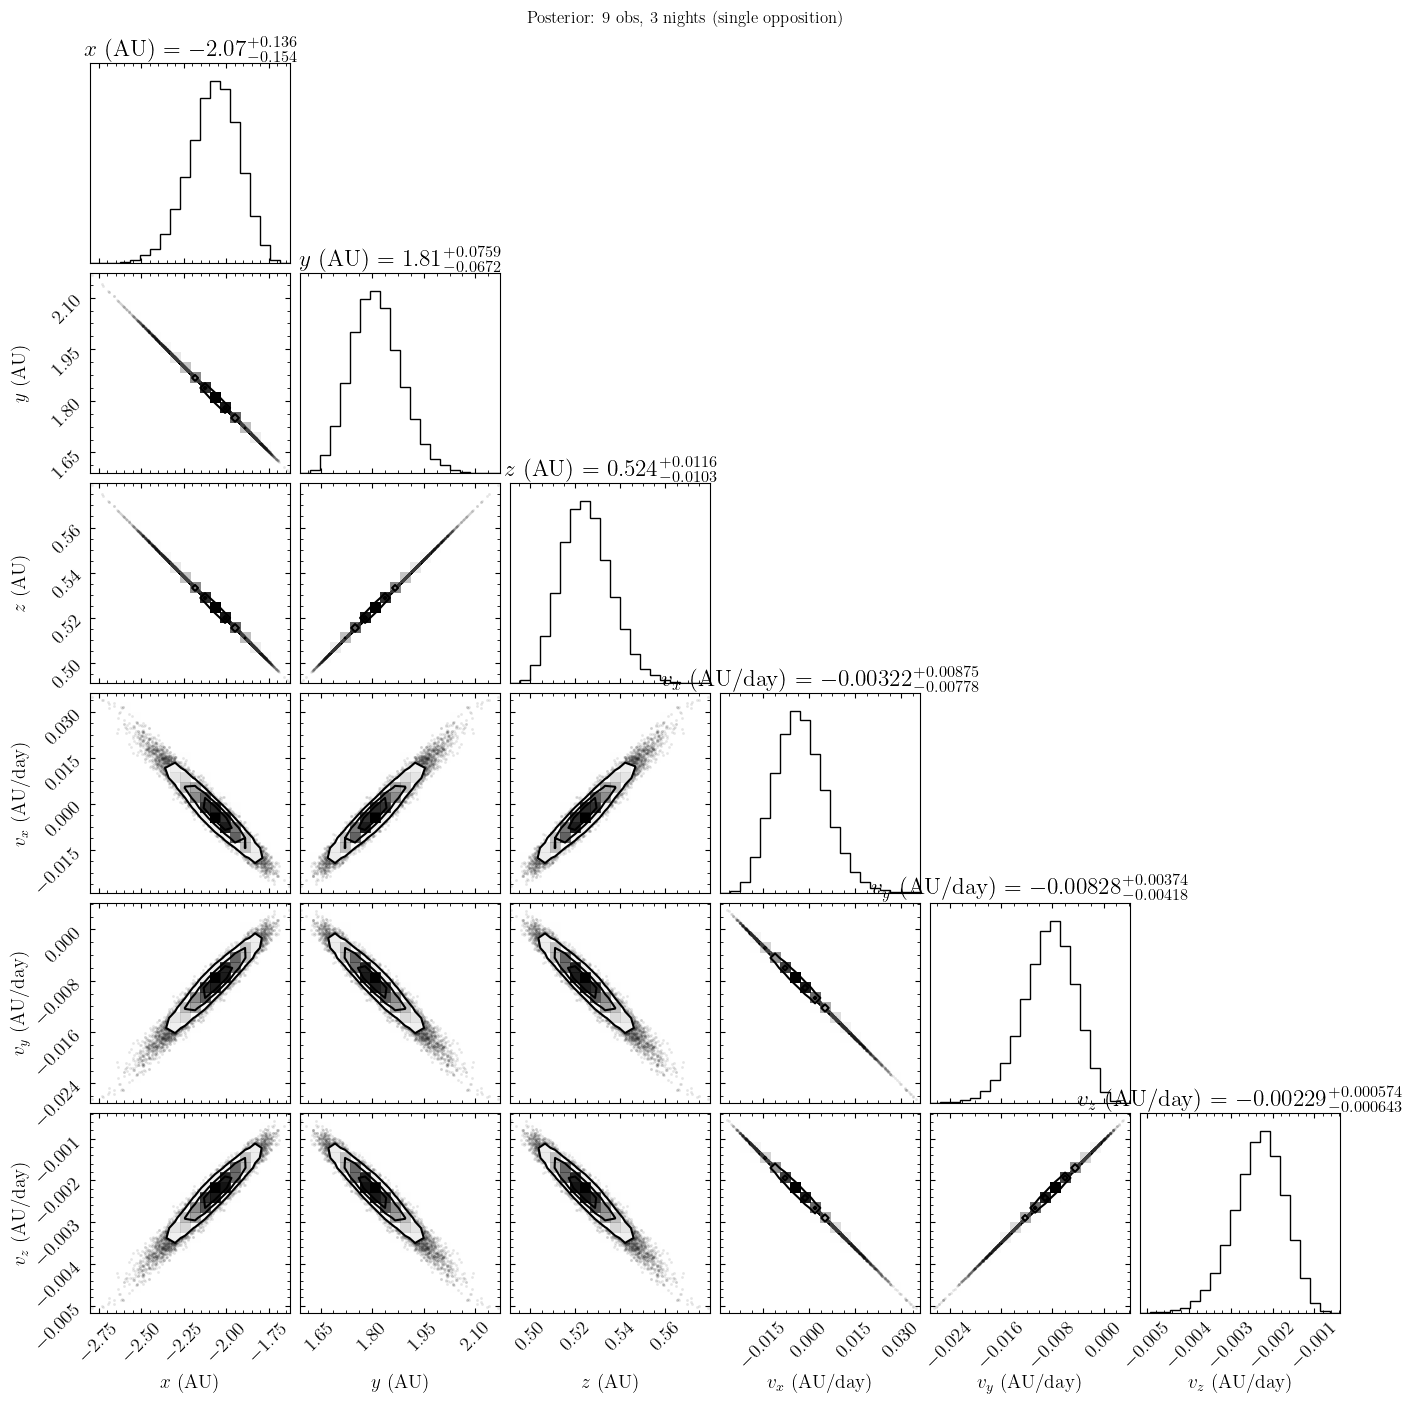

In [8]:
cartesian_labels = [
    "$x$ (AU)",
    "$y$ (AU)",
    "$z$ (AU)",
    "$v_x$ (AU/day)",
    "$v_y$ (AU/day)",
    "$v_z$ (AU/day)",
]


fig = corner.corner(
    flat_samples,
    labels=cartesian_labels,
    show_titles=True,
    title_fmt=".3g",
)
plt.suptitle(
    "Posterior: 9 obs, 3 nights (single opposition)",
    y=1.01,
    fontsize=12,
)
plt.show()

## Part 2: How the posterior shrinks with more data

Short arcs within a single opposition leave parts of the Cartesian state vector poorly constrained, especially the line-of-sight position and velocity components. Adding nights from the same opposition helps, but adding data from a *second* opposition (a year or so later) is far more powerful: the Earth has completed nearly one full orbit while the asteroid has moved appreciably, providing strong leverage on the heliocentric distance and motion.

Below we run three MCMC chains:
1. The baseline: three nights from January 2025
2. Extended single opposition: seven nights in January 2025
3. Two oppositions: the seven January 2025 nights plus three nights in October 2025

All chains share the same true starting state and the same sampler settings.

In [9]:
def run_mcmc(obs_set, nwalkers=32, nsteps=3000, discard=500, thin=5, seed=42):
    """Create a fresh Particle, set up its static likelihood path, and run emcee.

    Parameters
    ----------
    obs_set : Observations
        The set of observations to condition on.
    nwalkers : int
        Number of emcee walkers.
    nsteps : int
        Total steps per walker (burn-in included).
    discard : int
        Number of burn-in steps to discard before thinning.
    thin : int
        Thinning factor applied after discarding burn-in.
    seed : int
        RNG seed for walker initialization.

    Returns
    -------
    np.ndarray
        Flat sample array of shape (N, 6) in Cartesian state-vector components
        [x, y, z, vx, vy, vz] in AU and AU/day.
    """
    # A new Particle is created for each obs_set so that static_residuals
    # is precomputed for the correct time range and observation count.
    particle = Particle(
        x=true_x0,
        v=true_v0,
        time=times[0],  # reference epoch: first observation from Part 1
        name="274301 Wikipedia",
        observations=obs_set,
    )

    def _log_prob(params):
        state = CartesianState(
            x=jnp.array(params[:3]).reshape(1, 3),
            v=jnp.array(params[3:]).reshape(1, 3),
            acceleration_func_kwargs={"c2": SPEED_OF_LIGHT**2},
            relative_time=jnp.array(0.0),
            time_reference=particle._t_ref_jd,
        )
        return float(-0.5 * jnp.sum(particle.static_residuals(state) ** 2))

    p0_map = np.concatenate([true_x0, true_v0])
    scale = np.array([1e-7, 1e-7, 1e-7, 1e-10, 1e-10, 1e-10])
    init = p0_map + scale * np.random.default_rng(seed).standard_normal((nwalkers, 6))

    samp = emcee.EnsembleSampler(nwalkers, 6, _log_prob)
    samp.run_mcmc(init, nsteps, progress=True)

    flat = samp.get_chain(discard=discard, thin=thin, flat=True)
    print(f"  acceptance fraction: {np.mean(samp.acceptance_fraction):.3f}")
    return flat

### Run 1 — baseline: 3 nights, single opposition

In [10]:
print("Run 1: 3 nights (Jan 1, 2, 5 2025)")
samples1 = run_mcmc(obs)

Run 1: 3 nights (Jan 1, 2, 5 2025)


100%|██████████| 3000/3000 [00:34<00:00, 86.26it/s]

  acceptance fraction: 0.516


### Run 2 — extended arc: 7 nights, single opposition

We add four more nights in January 2025 and use the `+` operator to combine them with the baseline observations.

In [11]:
nights_extra = [Time(f"2025-01-{d:02d} 07:00") for d in [8, 12, 17, 20]]
times_extra = []
for n in nights_extra:
    times_extra.extend([n + i * 1 * u.hour for i in range(3)])
times_extra = Time(times_extra)

obj = Horizons(id="274301", location="695@399", epochs=times_extra.utc.jd)
pts = obj.ephemerides(extra_precision=True, quantities="1")
coords_extra = SkyCoord(pts["RA"], pts["DEC"], unit=(u.deg, u.deg))
times_extra = Time(pts["datetime_jd"], format="jd", scale="utc")

obs_extra = Observations(
    observed_coordinates=coords_extra,
    times=times_extra,
    observatories="kitt peak",
    astrometric_uncertainties=1 * u.arcsec,
)

# Combine with the baseline using the + operator
obs_ext = obs + obs_extra

print(f"Run 2: {len(obs_ext.ra)} observations over 7 nights")
samples2 = run_mcmc(obs_ext)

Run 2: 21 observations over 7 nights


100%|██████████| 3000/3000 [00:39<00:00, 75.32it/s]

  acceptance fraction: 0.520


### Run 3 — two oppositions: Jan 2025 + Oct 2025

Adding observations from a second epoch roughly nine months later extends the arc to cover a substantial fraction of the asteroid's orbital period, strongly constraining the Cartesian state vector.

In [12]:
nights_opp2 = [Time(f"2025-10-{d:02d} 07:00") for d in [1, 5, 10]]
times_opp2 = []
for n in nights_opp2:
    times_opp2.extend([n + i * 1 * u.hour for i in range(3)])
times_opp2 = Time(times_opp2)

obj = Horizons(id="274301", location="695@399", epochs=times_opp2.utc.jd)
pts = obj.ephemerides(extra_precision=True, quantities="1")
coords_opp2 = SkyCoord(pts["RA"], pts["DEC"], unit=(u.deg, u.deg))
times_opp2 = Time(pts["datetime_jd"], format="jd", scale="utc")

obs_opp2 = Observations(
    observed_coordinates=coords_opp2,
    times=times_opp2,
    observatories="kitt peak",
    astrometric_uncertainties=1 * u.arcsec,
)

obs_all = obs_ext + obs_opp2

print(f"Run 3: {len(obs_all.ra)} observations across two epochs")
samples3 = run_mcmc(obs_all)

Run 3: 30 observations across two epochs


100%|██████████| 3000/3000 [00:59<00:00, 50.33it/s]

  acceptance fraction: 0.521


### Overlaying the three posteriors

We show only the Cartesian position subspace $(x, y, z)$ for readability and overlay 68\% and 95\% credible contours for each run.

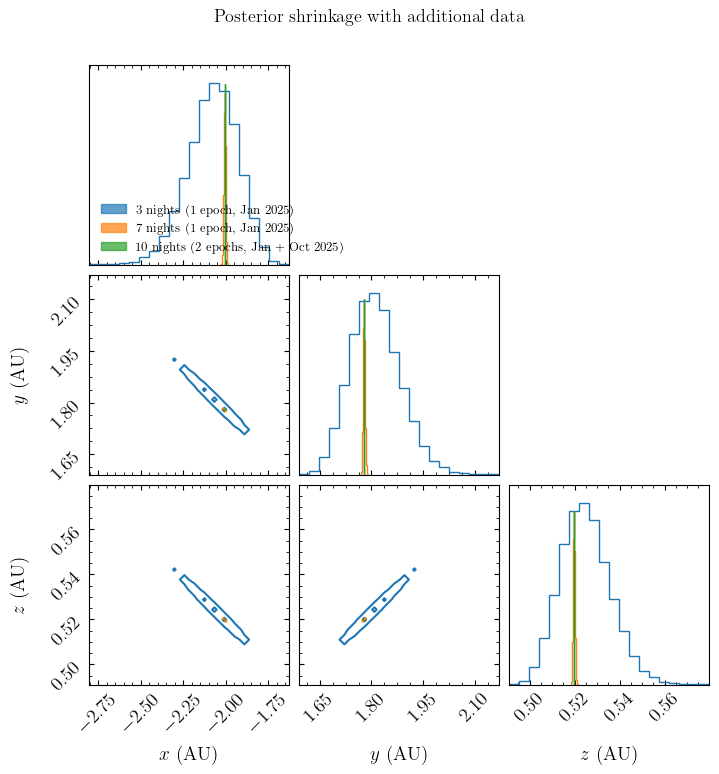

In [13]:
colors = ["C0", "C1", "C2"]
labels_runs = [
    "3 nights (1 epoch, Jan 2025)",
    "7 nights (1 epoch, Jan 2025)",
    "10 nights (2 epochs, Jan + Oct 2025)",
]

corner_kwargs = dict(
    plot_density=False,
    plot_datapoints=False,
    levels=[0.68, 0.95],
    no_fill_contours=False,
    contourf_kwargs={"alpha": 0.25},
)

fig = corner.corner(
    samples1[:, :3],
    labels=cartesian_labels[:3],
    color=colors[0],
    **corner_kwargs,
)
corner.corner(samples2[:, :3], fig=fig, color=colors[1], **corner_kwargs)
corner.corner(samples3[:, :3], fig=fig, color=colors[2], **corner_kwargs)

handles = [
    mpatches.Patch(color=c, alpha=0.7, label=l) for c, l in zip(colors, labels_runs)
]
fig.axes[0].legend(handles=handles, loc="lower left", frameon=False, fontsize=9)
plt.suptitle("Posterior shrinkage with additional data", y=1.02, fontsize=13)
plt.show()

## Part 3: Batched likelihoods with `System`

Everything above evaluated the likelihood one walker at a time: emcee's default mode calls `log_prob` separately for each walker, and each call runs `Particle.static_residuals` on a single state. For an affine-invariant ensemble this leaves performance on the table — the walkers are independent evaluations of the *same* forward model and could be computed together.

When you pass an `Observations` object to a `System`, jorbit builds a **batched** forward model that scores a whole `(P, 6)` stack of candidate states in one vectorized call, exposed as `System.loglike` (alongside `System.residuals`, `System.chi2`, and `System.model_radec`). This is exactly the interface emcee's [`vectorize=True`](https://emcee.readthedocs.io/en/stable/tutorials/parallel/#vectorized) mode expects: each step, the active half-ensemble of walkers is handed to `log_prob` as a single `(nwalkers/2, ndim)` array.

A few things to keep in mind:

- The component particles of a `System` are dynamically **independent** — they could be entirely different asteroids. Supplying `observations` means every state in the batch is scored against the same shared data. Here we exploit that to treat the emcee walkers as the batch axis: one template `System`, an arbitrary `(P, 6)` batch of candidate states per call.
- `System.loglike` uses the *dynamic* IAS15 dense path (a single bounded-arc buffer, no host-side stitching), not the *static* path from Part 1. For a gradient-free sampler like emcee that distinction is invisible; the two paths agree to sub-mas. The static path remains the route to take when you need reverse-mode gradients (e.g. for HMC/NUTS).
- If the observation arc is long enough to exceed one dense buffer, the affected states return `-inf` (the schedule is shared across the batch, so truncation is batch-wide) — the sampler simply rejects them rather than crashing. For arcs that long, fall back to `System.ephemeris`.

We reuse the same nine-observation baseline from Part 1 so we can check the batched path lands on the same posterior.

In [14]:
from jorbit import System

# Reuse the Part 1 particle (built from `obs`) and wrap it in a System carrying the
# same observations. The batched forward model is built at construction time; no
# explicit "compile" step and no JAX boilerplate are needed.
system = System(
    particles=[p],
    observations=obs,
    gravity="default solar system",
)


# System.loglike maps a (P, 6) batch of candidate states -> (P,) log-likelihoods,
# which is exactly the array signature emcee's vectorize=True mode expects. The
# whole hand-rolled CartesianState / SPEED_OF_LIGHT / offset dance from Part 1 is
# gone: you hand loglike a plain (P, 6) array of [x, y, z, vx, vy, vz] at t_ref.
def log_prob_batched(coords):
    return np.asarray(system.loglike(jnp.asarray(coords)))


sampler_batched = emcee.EnsembleSampler(
    nwalkers, ndim, log_prob_batched, vectorize=True
)
sampler_batched.run_mcmc(initial_pos, 3000, progress=True)

flat_batched = sampler_batched.get_chain(discard=500, thin=5, flat=True)
print(f"Acceptance fraction: {np.mean(sampler_batched.acceptance_fraction):.3f}")

100%|██████████| 3000/3000 [00:31<00:00, 95.57it/s] 

Acceptance fraction: 0.516


### Cross-check against Part 1

The batched `System` path and the per-walker `static_residuals` path condition on the *same* nine observations, so their posteriors should agree to within sampling noise. (They will not be bit-for-bit identical: `System.loglike` uses the full per-observation covariance normalization and the dynamic dense integrator, whereas Part 1 used an isotropic 1 arcsec chi-square evaluated on the static path. These differ only by an additive constant in the log-probability, which does not affect the sampled distribution.) Overlaying the two confirms they land on the same posterior:

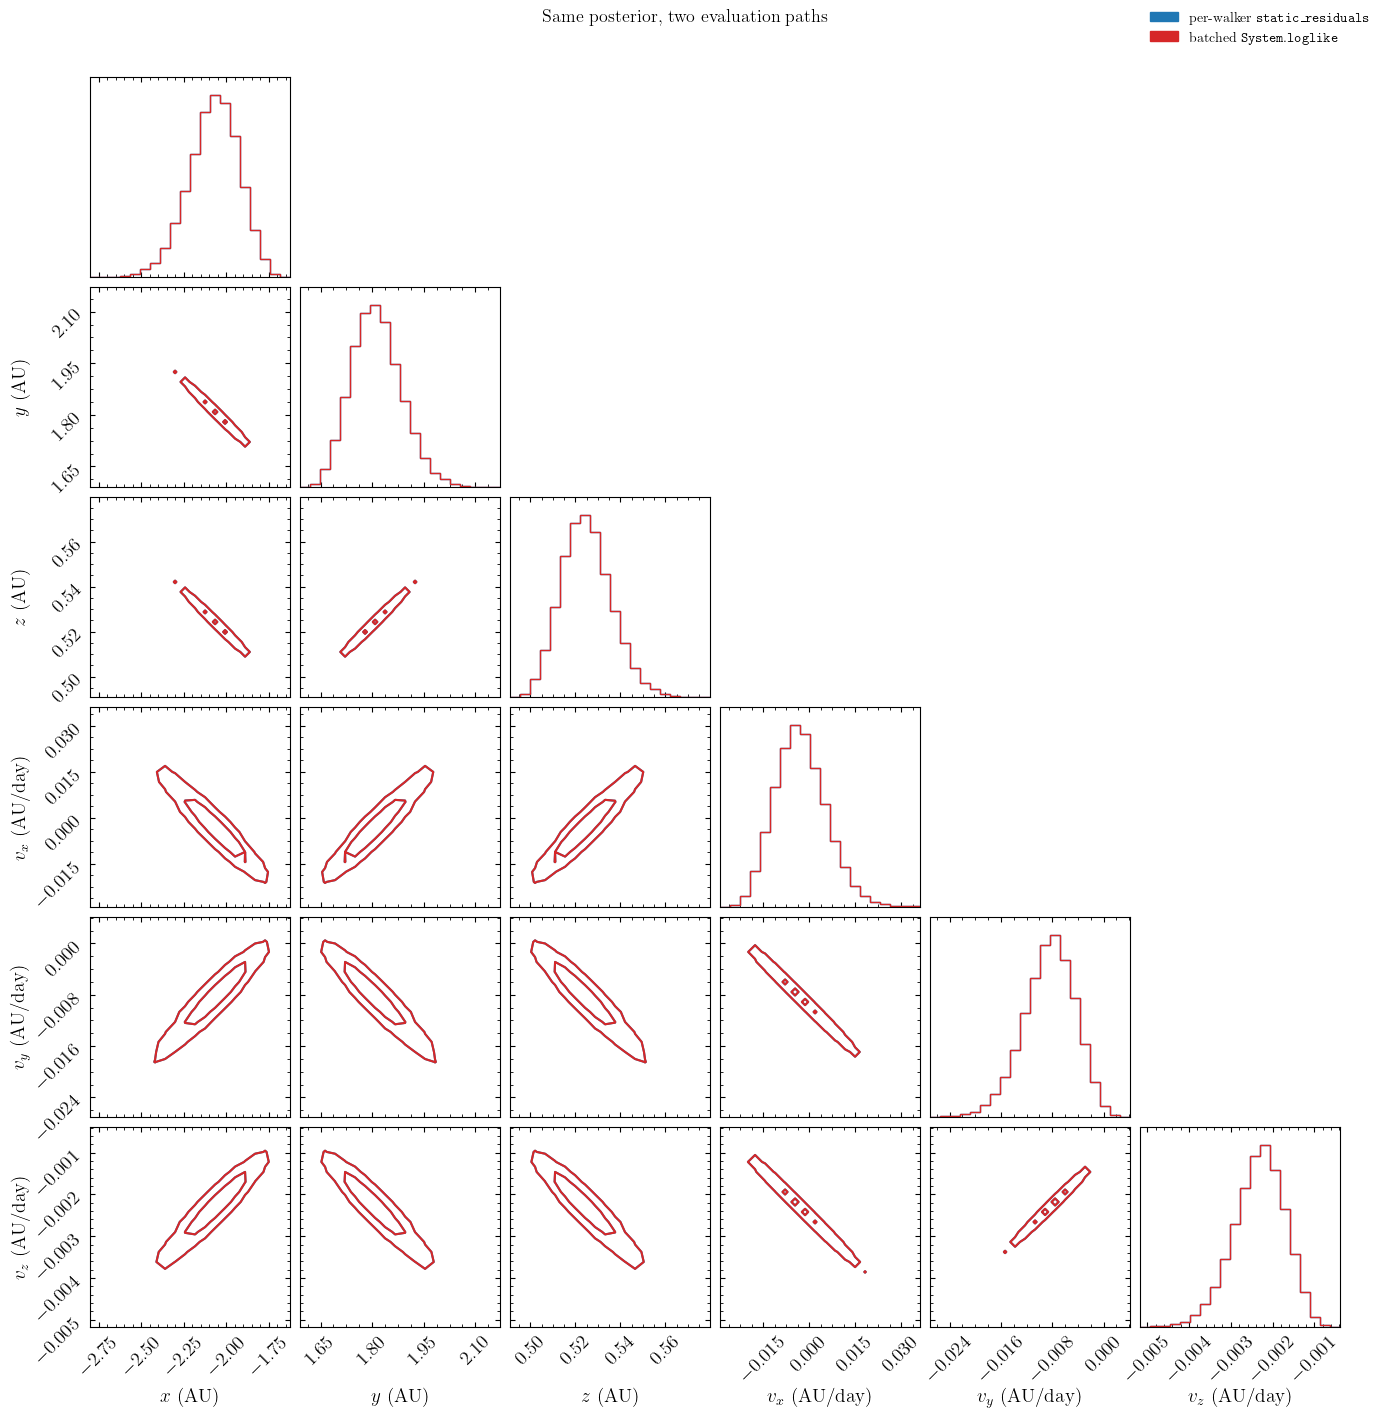

In [15]:
fig = corner.corner(
    flat_samples,
    labels=cartesian_labels,
    color="C0",
    plot_density=False,
    plot_datapoints=False,
    levels=[0.68, 0.95],
)
corner.corner(
    flat_batched,
    fig=fig,
    color="C3",
    plot_density=False,
    plot_datapoints=False,
    levels=[0.68, 0.95],
)

handles = [
    mpatches.Patch(color="C0", label=r"per-walker $\mathtt{static\_residuals}$"),
    mpatches.Patch(color="C3", label=r"batched $\mathtt{System.loglike}$"),
]
fig.legend(handles=handles, loc="upper right", frameon=False, fontsize=10)
plt.suptitle("Same posterior, two evaluation paths", y=1.02, fontsize=13)
plt.show()